In [1]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import seaborn as sns
print(sns.__version__)

0.13.2


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
 df = pd.read_csv("data-export (1).csv")

In [4]:
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [7]:
df.columns = df.iloc[0]
df = df.drop(index = 0).reset_index(drop = True)
df.columns  = ["Channel Group", "DateHour", "Users", "Sessions", "Engaged Sessions", "Average Engagment Time Per Session", "Engaged Sessions Per User", "Events Per Session", "Engagement Rate", "Event Count"]

In [8]:
df.head()

,Channel Group,DateHour,Users,Sessions,Engaged Sessions,Average Engagment Time Per Session,Engaged Sessions Per User,Events Per Session,Engagement Rate,Event Count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [9]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Channel Group                       3182 non-null   object
 1   DateHour                            3182 non-null   object
 2   Users                               3182 non-null   object
 3   Sessions                            3182 non-null   object
 4   Engaged Sessions                    3182 non-null   object
 5   Average Engagment Time Per Session  3182 non-null   object
 6   Engaged Sessions Per User           3182 non-null   object
 7   Events Per Session                  3182 non-null   object
 8   Engagement Rate                     3182 non-null   object
 9   Event Count                         3182 non-null   object
dtypes: object(10)
memory usage: 248.7+ KB


In [10]:
df["DateHour"] = pd.to_datetime(df["DateHour"], format = "%Y%m%d%H", errors = 'coerce')
numeric_cols = df.columns.drop(["Channel Group", "DateHour"])
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors = 'coerce')
df["Hour"] = df["DateHour"].dt.hour

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Channel Group                       3182 non-null   object        
 1   DateHour                            3182 non-null   datetime64[ns]
 2   Users                               3182 non-null   int64         
 3   Sessions                            3182 non-null   int64         
 4   Engaged Sessions                    3182 non-null   int64         
 5   Average Engagment Time Per Session  3182 non-null   float64       
 6   Engaged Sessions Per User           3182 non-null   float64       
 7   Events Per Session                  3182 non-null   float64       
 8   Engagement Rate                     3182 non-null   float64       
 9   Event Count                         3182 non-null   int64         
 10  Hour                    

In [12]:
df.head()

,Channel Group,DateHour,Users,Sessions,Engaged Sessions,Average Engagment Time Per Session,Engaged Sessions Per User,Events Per Session,Engagement Rate,Event Count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


In [13]:
df.describe()

,DateHour,Users,Sessions,Engaged Sessions,Average Engagment Time Per Session,Engaged Sessions Per User,Events Per Session,Engagement Rate,Event Count,Hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441216,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


In [14]:
df.isnull().sum()

Channel Group                         0
DateHour                              0
Users                                 0
Sessions                              0
Engaged Sessions                      0
Average Engagment Time Per Session    0
Engaged Sessions Per User             0
Events Per Session                    0
Engagement Rate                       0
Event Count                           0
Hour                                  0
dtype: int64

In [15]:
df["Channel Group"].unique()

array(['Direct', 'Organic Social', 'Organic Search', 'Referral',
       'Unassigned', 'Organic Video', 'Email'], dtype=object)

In [16]:
df["Channel Group"].value_counts()

Channel Group
Direct            672
Organic Social    672
Organic Search    672
Referral          672
Unassigned        366
Organic Video     125
Email               3
Name: count, dtype: int64

In [17]:
print("Total Sessions:", df["Sessions"].sum())
print("Total Users:", df["Users"].sum())

Total Sessions: 162895
Total Users: 133440


In [21]:
print(df["DateHour"].duplicated().sum())

2510


In [22]:
df["DateHour"].value_counts().head()

DateHour
2024-04-24 17:00:00    6
2024-04-25 22:00:00    6
2024-04-21 16:00:00    6
2024-04-24 16:00:00    6
2024-04-09 15:00:00    6
Name: count, dtype: int64

In [23]:
sessions_time = df.groupby("DateHour")["Sessions"].sum().reset_index()

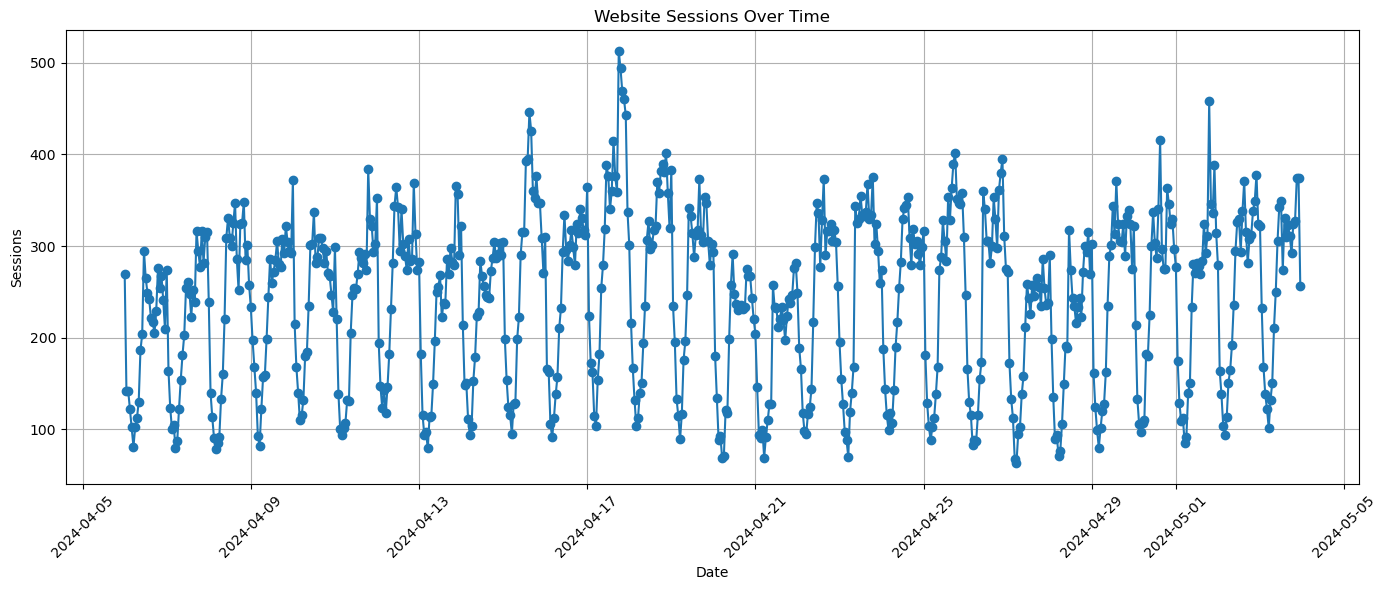

In [24]:
plt.figure(figsize=(14,6))

plt.plot(
    sessions_time["DateHour"],
    sessions_time["Sessions"],
    marker='o'
)

plt.title("Website Sessions Over Time")
plt.xlabel("Date")
plt.ylabel("Sessions")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

In [25]:
# Calculate Bounce Rate
df["Bounce Rate"] = (1 - df["Engagement Rate"]) * 100

print("Total Sessions:", df["Sessions"].sum())
print("Total Users:", df["Users"].sum())
print("Average Bounce Rate:", round(df["Bounce Rate"].mean(), 2), "%")

Total Sessions: 162895
Total Users: 133440
Average Bounce Rate: 49.66 %


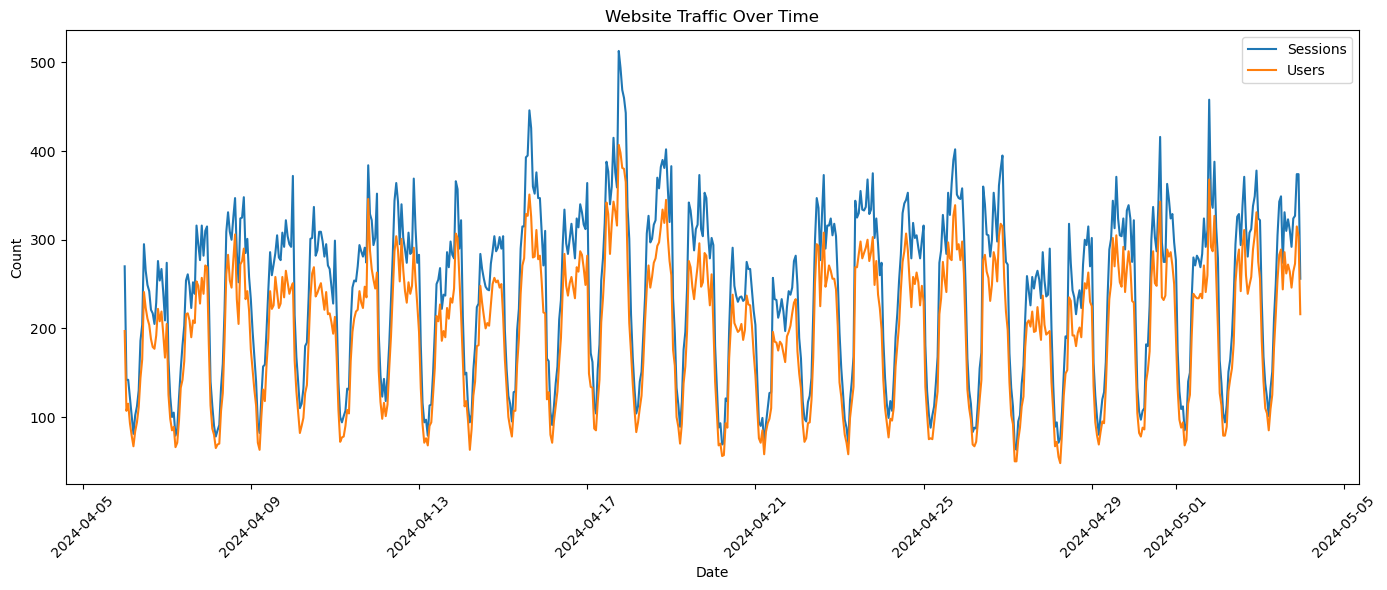

In [26]:
traffic = df.groupby("DateHour")[["Sessions", "Users"]].sum().reset_index()

plt.figure(figsize=(14,6))

plt.plot(traffic["DateHour"], traffic["Sessions"], label="Sessions")
plt.plot(traffic["DateHour"], traffic["Users"], label="Users")

plt.title("Website Traffic Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
traffic_source = df.groupby("Channel Group")["Sessions"].sum().sort_values(ascending=False)

print(traffic_source)

Channel Group
Organic Social    60627
Direct            37203
Organic Search    33372
Referral          30990
Unassigned          559
Organic Video       141
Email                 3
Name: Sessions, dtype: int64


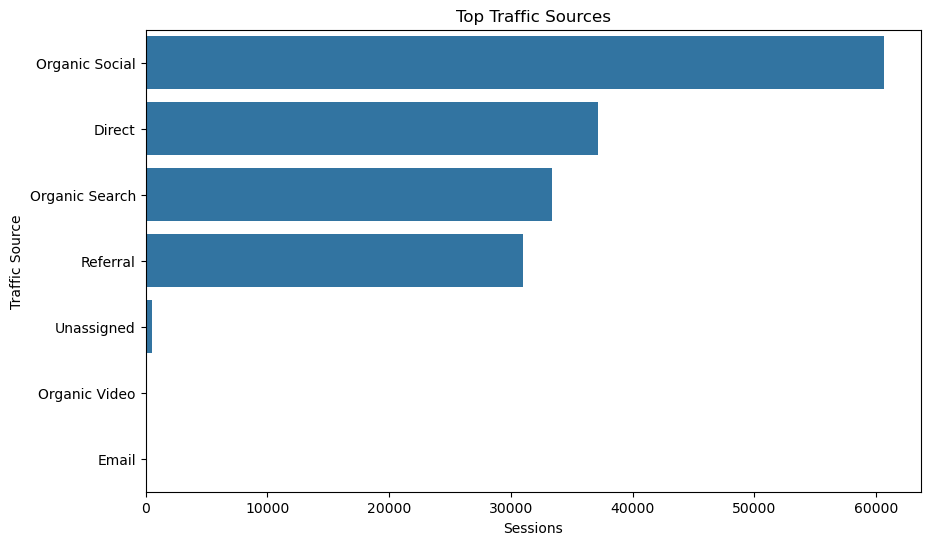

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=traffic_source.values,
    y=traffic_source.index
)

plt.title("Top Traffic Sources")
plt.xlabel("Sessions")
plt.ylabel("Traffic Source")

plt.show()

In [29]:
engagement = df.groupby("Channel Group")["Average Engagment Time Per Session"].mean()

print(engagement)

Channel Group
Direct             45.533104
Email              72.666667
Organic Search     47.005018
Organic Social     53.493681
Organic Video     180.360000
Referral           92.660842
Unassigned         78.957923
Name: Average Engagment Time Per Session, dtype: float64


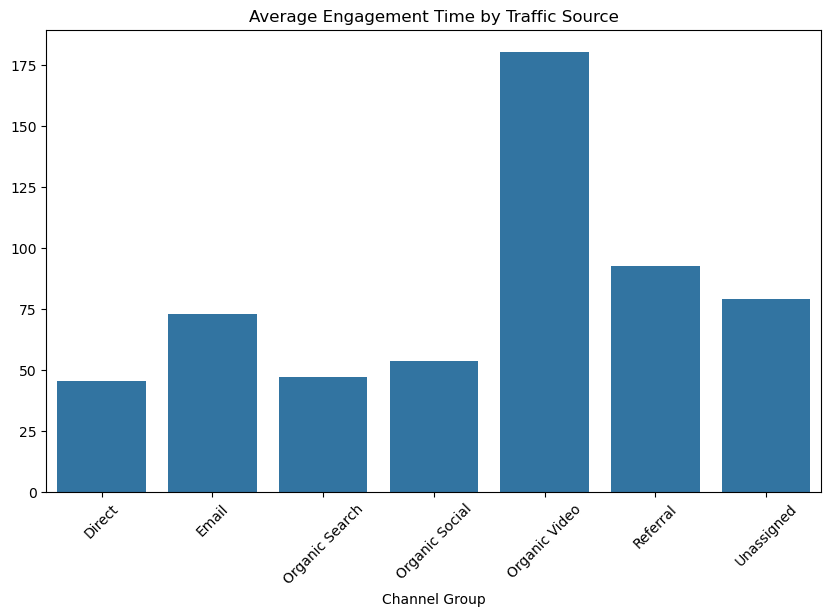

In [30]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=engagement.index,
    y=engagement.values
)

plt.xticks(rotation=45)

plt.title("Average Engagement Time by Traffic Source")

plt.show()

In [31]:
print("Conversion Rate: Not Available in Dataset")
print("Goal Completions: Not Available in Dataset")

Conversion Rate: Not Available in Dataset
Goal Completions: Not Available in Dataset


In [32]:
print("Page-level analysis cannot be performed because the dataset does not contain Page Title or Landing Page information.")

Page-level analysis cannot be performed because the dataset does not contain Page Title or Landing Page information.


In [33]:
print("========== DASHBOARD ==========")

print("Total Users:", df["Users"].sum())

print("Total Sessions:", df["Sessions"].sum())

print("Average Engagement Rate:", round(df["Engagement Rate"].mean()*100,2), "%")

print("Average Bounce Rate:", round(df["Bounce Rate"].mean(),2), "%")

print("Average Session Time:", round(df["Average Engagment Time Per Session"].mean(),2), "seconds")

print("Total Event Count:", df["Event Count"].sum())

========== DASHBOARD ==========
Total Users: 133440
Total Sessions: 162895
Average Engagement Rate: 50.34 %
Average Bounce Rate: 49.66 %
Average Session Time: 66.64 seconds
Total Event Count: 770911


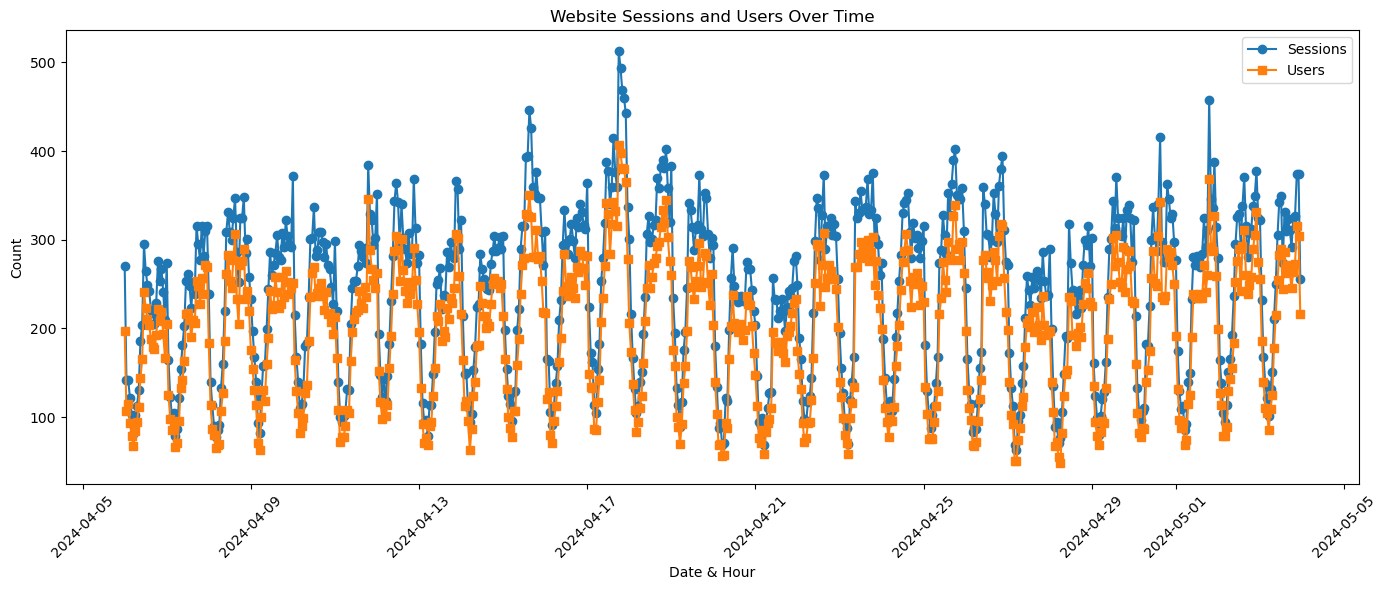

In [34]:
traffic = df.groupby("DateHour")[["Sessions", "Users"]].sum().reset_index()

plt.figure(figsize=(14,6))

plt.plot(traffic["DateHour"], traffic["Sessions"], marker="o", label="Sessions")
plt.plot(traffic["DateHour"], traffic["Users"], marker="s", label="Users")

plt.title("Website Sessions and Users Over Time")
plt.xlabel("Date & Hour")
plt.ylabel("Count")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_12456\3244456575.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


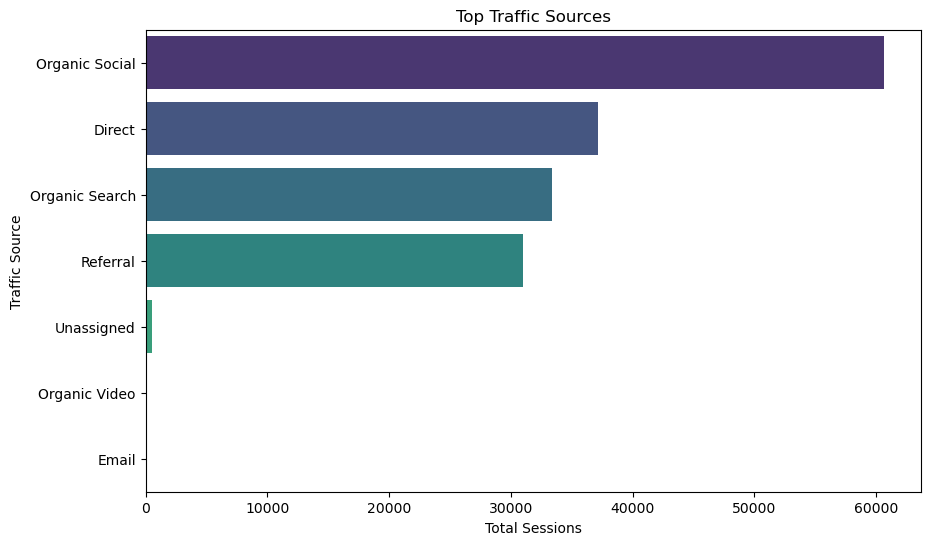

In [35]:
traffic_source = df.groupby("Channel Group")["Sessions"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=traffic_source.values,
    y=traffic_source.index,
    palette="viridis"
)

plt.title("Top Traffic Sources")
plt.xlabel("Total Sessions")
plt.ylabel("Traffic Source")

plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_12456\270412760.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


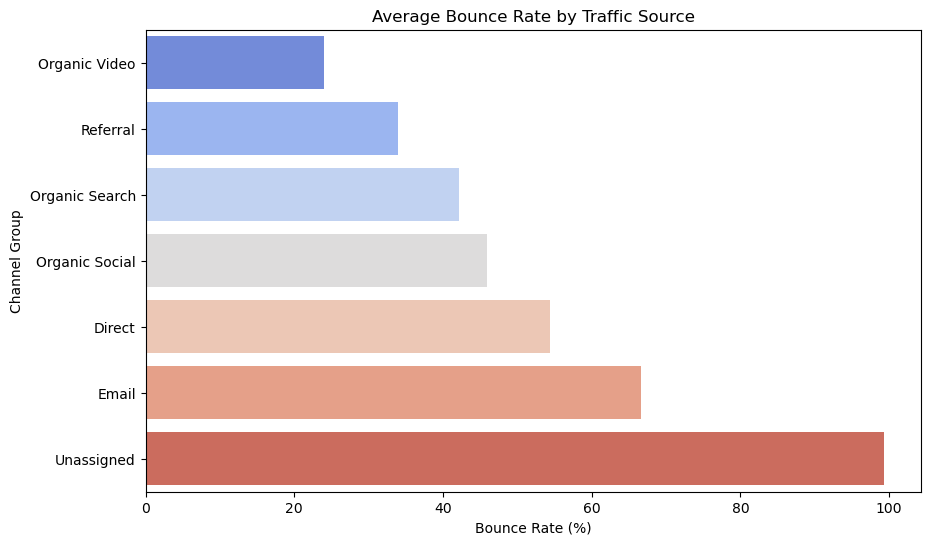

In [36]:
bounce = df.groupby("Channel Group")["Bounce Rate"].mean().sort_values()

plt.figure(figsize=(10,6))

sns.barplot(
    x=bounce.values,
    y=bounce.index,
    palette="coolwarm"
)

plt.title("Average Bounce Rate by Traffic Source")
plt.xlabel("Bounce Rate (%)")

plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_12456\2844832558.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


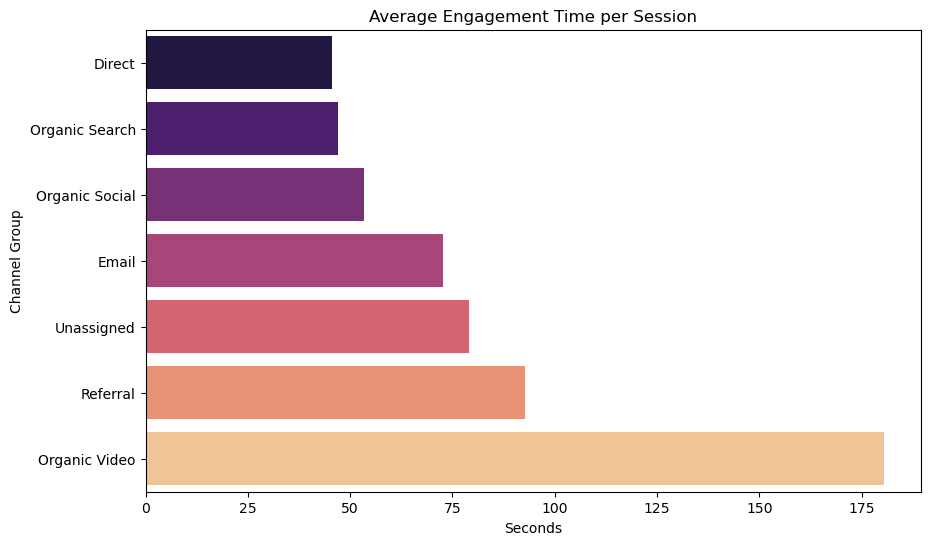

In [37]:
engagement = df.groupby("Channel Group")["Average Engagment Time Per Session"].mean().sort_values()

plt.figure(figsize=(10,6))

sns.barplot(
    x=engagement.values,
    y=engagement.index,
    palette="magma"
)

plt.title("Average Engagement Time per Session")
plt.xlabel("Seconds")

plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_12456\670321633.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


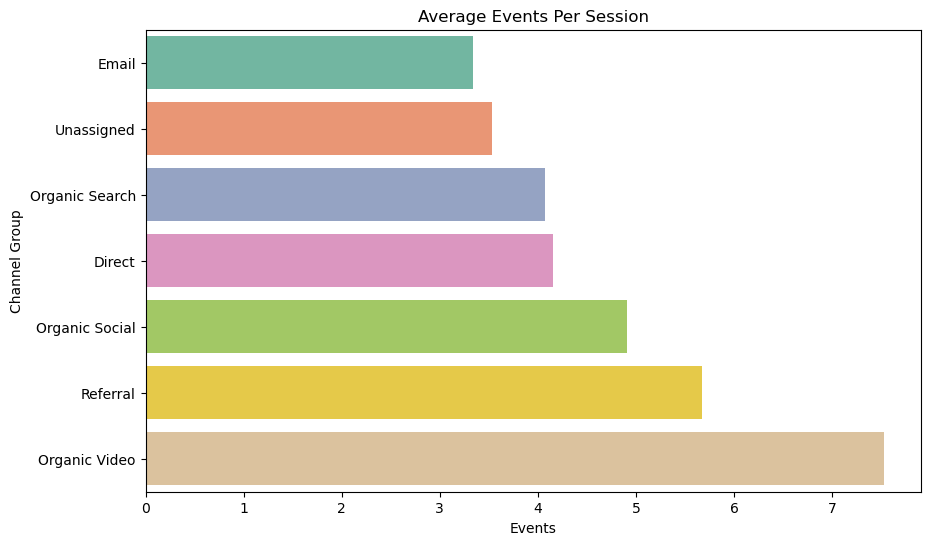

In [38]:
events = df.groupby("Channel Group")["Events Per Session"].mean().sort_values()

plt.figure(figsize=(10,6))

sns.barplot(
    x=events.values,
    y=events.index,
    palette="Set2"
)

plt.title("Average Events Per Session")
plt.xlabel("Events")

plt.show()

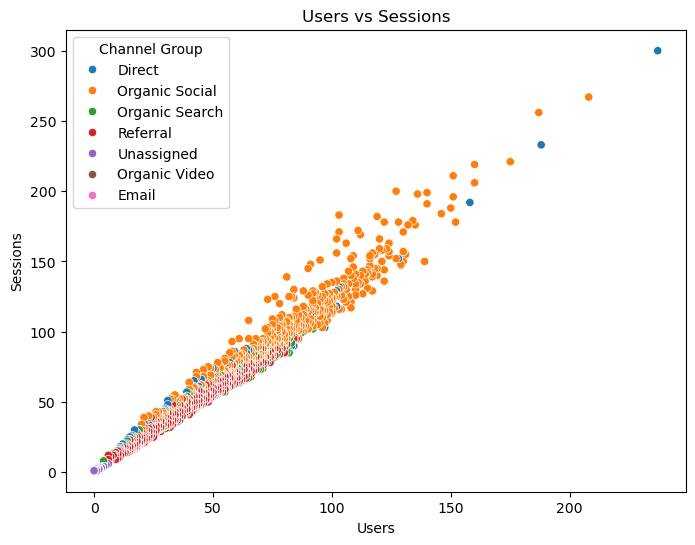

In [39]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Users",
    y="Sessions",
    hue="Channel Group"
)

plt.title("Users vs Sessions")

plt.show()

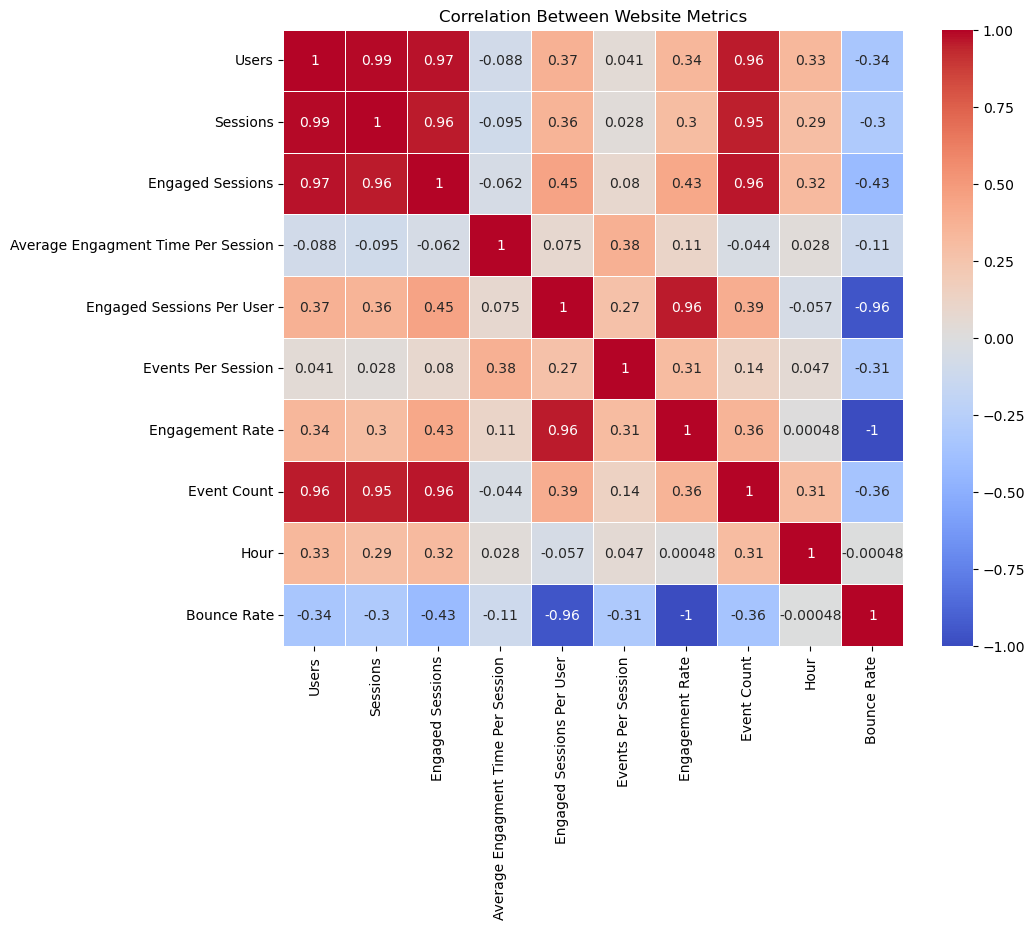

In [40]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Between Website Metrics")

plt.show()

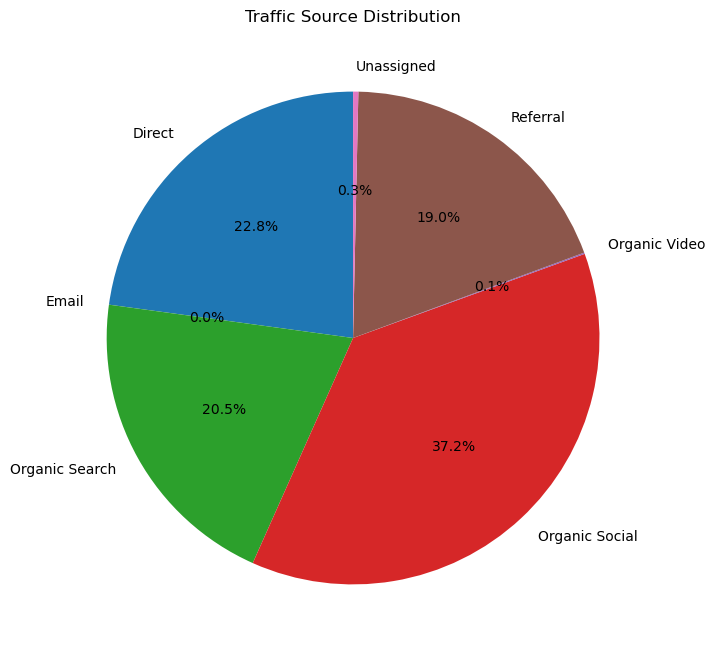

In [41]:
source = df.groupby("Channel Group")["Sessions"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    source,
    labels=source.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Traffic Source Distribution")

plt.show()

In [42]:
print("BUSINESS INSIGHTS")
print("- Organic traffic and Direct traffic are the major contributors to website sessions.")
print("- Higher engagement time indicates users are interacting more with the website.")
print("- Lower bounce rates suggest better user engagement.")
print("- Event count increases with the number of sessions.")
print("- The correlation heatmap shows strong relationships among key traffic metrics.")
print("- Traffic trends help identify peak activity periods for better marketing decisions.")

BUSINESS INSIGHTS
- Organic traffic and Direct traffic are the major contributors to website sessions.
- Higher engagement time indicates users are interacting more with the website.
- Lower bounce rates suggest better user engagement.
- Event count increases with the number of sessions.
- The correlation heatmap shows strong relationships among key traffic metrics.
- Traffic trends help identify peak activity periods for better marketing decisions.


In [43]:
print("=" * 60)
print("CONCLUSION")
print("=" * 60)

print("""
The website traffic analysis shows valuable insights into user behavior
and traffic acquisition. Traffic source analysis helps identify which
channels generate the highest number of sessions and users. User
engagement metrics such as engagement rate, average engagement time,
and events per session provide a clear understanding of visitor
interaction with the website.

The correlation analysis reveals relationships among website metrics,
helping businesses make data-driven decisions. Overall, this analysis
can assist organizations in optimizing marketing strategies and
improving user engagement.

Note: The provided GA4 dataset does not include page-level information,
conversion rates, or goal completions. Therefore, these analyses could
not be performed.
""")

CONCLUSION

The website traffic analysis shows valuable insights into user behavior
and traffic acquisition. Traffic source analysis helps identify which
channels generate the highest number of sessions and users. User
engagement metrics such as engagement rate, average engagement time,
and events per session provide a clear understanding of visitor
interaction with the website.

The correlation analysis reveals relationships among website metrics,
helping businesses make data-driven decisions. Overall, this analysis
can assist organizations in optimizing marketing strategies and
improving user engagement.

Note: The provided GA4 dataset does not include page-level information,
conversion rates, or goal completions. Therefore, these analyses could
not be performed.



In [44]:
print("- Organic traffic and Direct traffic are the major contributors...")

- Organic traffic and Direct traffic are the major contributors...


In [45]:
top_source = df.groupby("Channel Group")["Sessions"].sum().idxmax()

print("BUSINESS INSIGHTS")
print(f"- {top_source} is the highest traffic source based on total sessions.")
print("- Higher engagement time indicates users are interacting more with the website.")
print("- Lower bounce rates suggest better user engagement.")
print("- Event count increases with the number of sessions.")
print("- The correlation heatmap shows relationships among website metrics.")
print("- Traffic trends help identify peak activity periods.")

BUSINESS INSIGHTS
- Organic Social is the highest traffic source based on total sessions.
- Higher engagement time indicates users are interacting more with the website.
- Lower bounce rates suggest better user engagement.
- Event count increases with the number of sessions.
- The correlation heatmap shows relationships among website metrics.
- Traffic trends help identify peak activity periods.


In [46]:
df.to_csv("Website_Traffic_Cleaned.csv", index=False)